# Filtros y Queries con Chinook

In [ ]:
!pip install -q "ipython-sql" "prettytable==3.11.0"
!git clone https://github.com/lerocha/chinook-database.git #cargamos la bd chinook desde un repo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.9 MB/s eta 0:00:00
Cloning into 'chinook-database'...
remote: Enumerating objects: 3019, done.
remote: Counting objects: 100% (266/266), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 3019 (delta 228), reused 196 (delta 191), pack-reused 2753 (from 2)
Receiving objects: 100% (3019/3019), 25.21 MiB | 14.71 MiB/s, done.
Resolving deltas: 100% (2093/2093), done.


In [ ]:
# load the SQL magic extension
# https://github.com/catherinedevlin/ipython-sql
# this extension allows us to connect to DBs and issue SQL command
%load_ext sql
# now we can use the magic extension to connect to our SQLite DB
# use %sql to write an inline SQL command
# use %%sql to write SQL commands in a cell
%sql sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite

In [ ]:
%reload_ext sql

## SQL I


### 1. DDL — Definición de datos

```sql
-- Crear tabla
CREATE TABLE nombre_tabla (
    col1 TIPO [restriccion],
    col2 TIPO [restriccion],
    PRIMARY KEY (col1),
    FOREIGN KEY (col2) REFERENCES otra_tabla(col_pk)
);

-- Modificar tabla
ALTER TABLE tabla ADD COLUMN col TIPO;
ALTER TABLE tabla DROP COLUMN col CASCADE;
ALTER TABLE tabla ALTER COLUMN col SET DEFAULT valor;

-- Eliminar tabla
DROP TABLE IF EXISTS tabla;
```
---

### 2. DML — Manipulación de datos

```sql
-- Insertar
INSERT INTO tabla (col1, col2) VALUES (val1, val2);

-- Actualizar
UPDATE tabla SET col1 = valor WHERE condicion;

-- Eliminar
DELETE FROM tabla WHERE condicion;
--Ojo con el DELETE!
```

---

### 3. SELECT — Consultas

```sql
SELECT [DISTINCT] columnas
FROM tabla
WHERE condicion
GROUP BY columna
HAVING condicion_agregada
ORDER BY columna [ASC|DESC]
LIMIT n [OFFSET m];
```

#### Filtros y operadores

```sql
WHERE edad > 30
WHERE edad BETWEEN 20 AND 30
WHERE id IN (1, 20, 35)
WHERE id NOT IN (1, 20, 35)

--Like para búsqueda en textos
WHERE nombre LIKE '%Juanita%' -- % = cualquier substring
WHERE nombre LIKE '%Br_an%' -- _ = un carácter (varía en la posición _)
WHERE nombre LIKE '_o%'; -- Qué hace esto?
```

#### Funciones de agregación

```sql
COUNT(col) -- contar filas
SUM(col) -- suma
AVG(col) -- promedio
MIN(col) -- mínimo
MAX(col) -- máximo
```

#### Alias y agrupamiento (Ejemplo)

```sql
SELECT PlaylistId, COUNT(TrackId) AS cnt
FROM PlaylistTrack
GROUP BY PlaylistId
HAVING cnt > 100;
```

---

### 4. JOINs

```sql
-- Producto cartesiano (n×m filas)
SELECT * FROM t1 CROSS JOIN t2;

-- Inner Join (solo filas coincidentes)
SELECT * FROM t1 JOIN t2 ON t1.id = t2.id;

-- Notación alternativa (equivalente a INNER JOIN)
SELECT * FROM t1, t2 WHERE t1.id = t2.id;

-- Outer Joins
SELECT * FROM t1 LEFT JOIN t2 ON t1.id = t2.id;
SELECT * FROM t1 RIGHT JOIN t2 ON t1.id = t2.id;
SELECT * FROM t1 FULL JOIN t2 ON t1.id = t2.id;

-- Múltiples JOINs encadenados
SELECT * FROM album
JOIN Artist USING (artistId)
JOIN Track USING (albumId);

--Fijarse que usamos las PK para conectar las relaciones, por qué?
```

---

### 5. Subconsultas

```sql
-- En WHERE con IN
SELECT name FROM track
WHERE AlbumId IN (
    SELECT AlbumId FROM album WHERE title = 'Californication'
);

-- Con NOT IN
SELECT name FROM track
WHERE AlbumId NOT IN (
    SELECT AlbumId FROM album WHERE title = 'Californication'
);

-- Subconsulta escalar en SELECT
SELECT c.FirstName,
    (SELECT COUNT(*) FROM invoice WHERE CustomerId = c.CustomerId) AS total
FROM customer c;
```
---

### 6. Operadores de conjunto (álgebra relacional)

```sql
-- Unión (elimina duplicados)
SELECT * FROM R UNION SELECT * FROM S;

-- Unión con duplicados
SELECT * FROM R UNION ALL SELECT * FROM S;

-- Intersección
SELECT * FROM R INTERSECT SELECT * FROM S;

-- Diferencia
SELECT * FROM R EXCEPT SELECT * FROM S;

-- Producto cartesiano
SELECT * FROM R, S;
```

---

### 7. Operaciones con strings

```sql
LENGTH(col)
UPPER(col)
LOWER(col)
SUBSTR(col, inicio, largo)
REPLACE(col, 'viejo', 'nuevo')
col1 || col2 -- concatenación
```

---

### 8. Fechas con `strftime`

```sql
-- Formato: "YYYY-MM-DD HH:MM:SS.SSS"
strftime('%Y', fecha) -- año
strftime('%m', fecha) -- mes
strftime('%d', fecha) -- día
strftime('%H', fecha) -- hora
strftime('%M', fecha) -- minutos

-- Ejemplo con filtro
SELECT * FROM invoice
WHERE strftime('%Y', InvoiceDate) = '2013';
```
---

### 9. Crear tabla desde consulta

```sql
CREATE TABLE nueva AS
SELECT col1, col2
FROM tabla_existente
WHERE condicion;
```

## Modelo de Chinook db

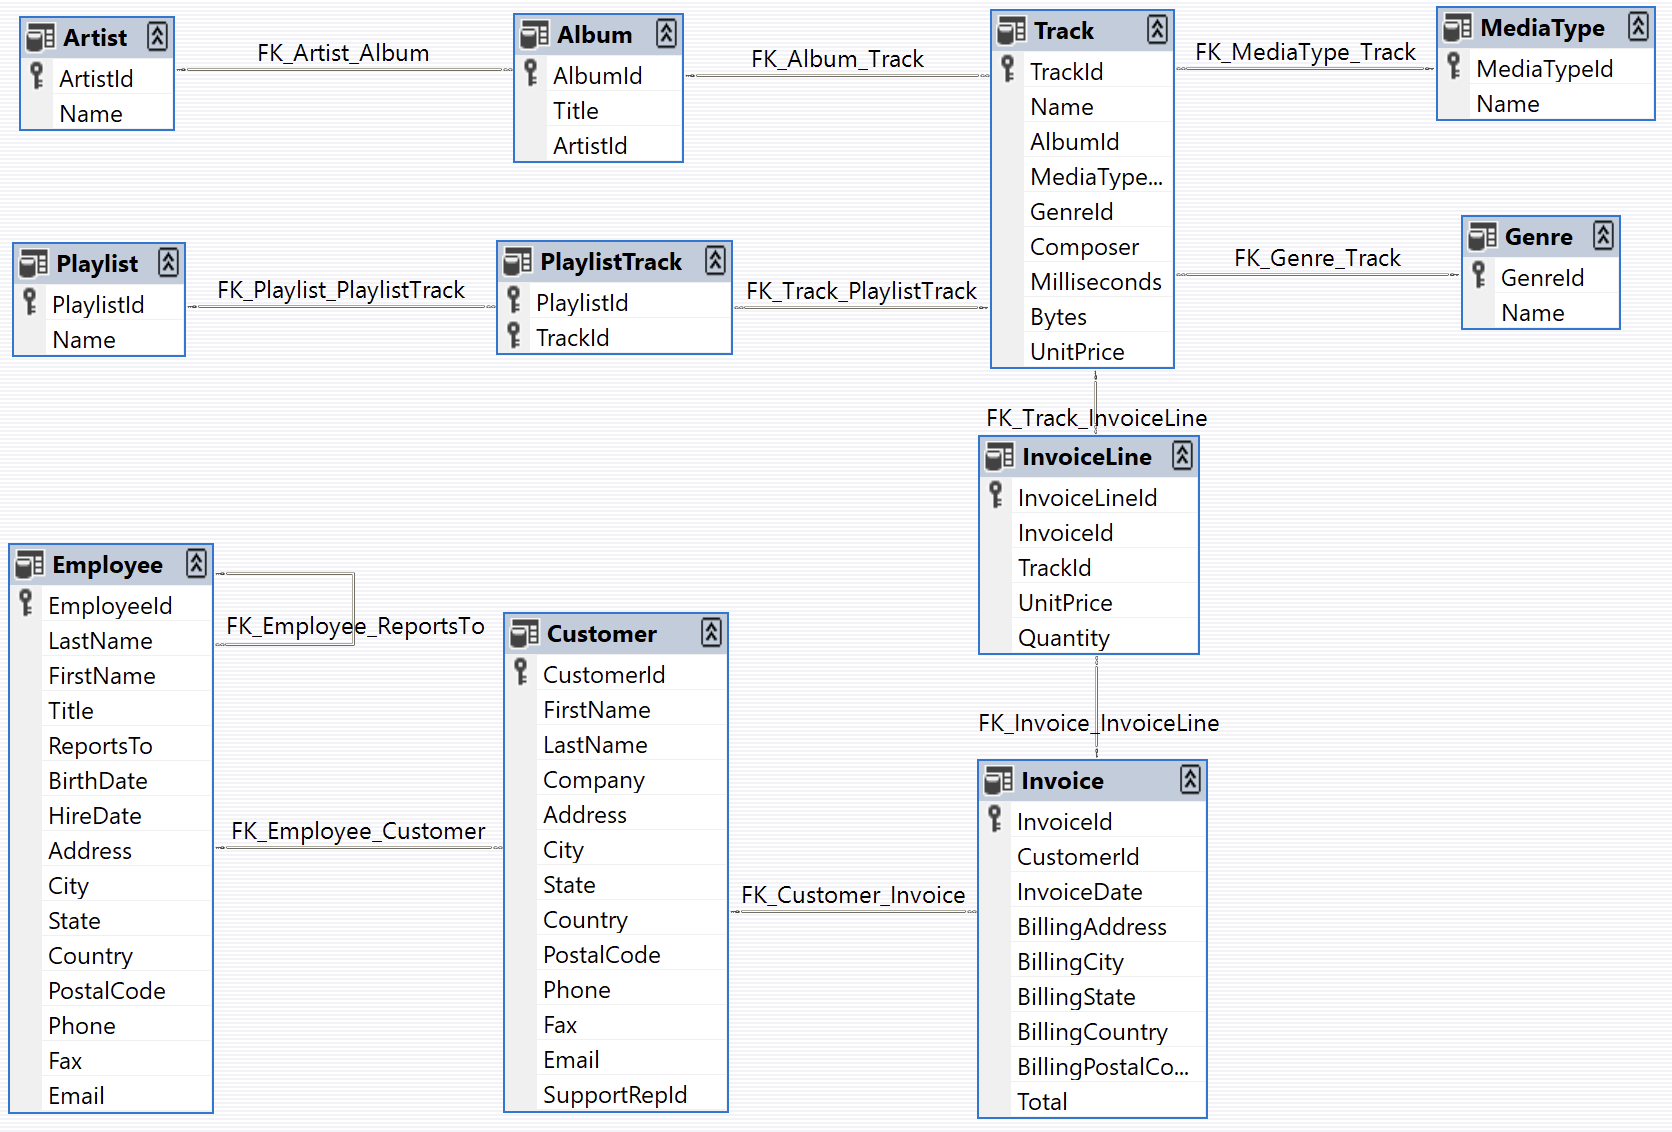

### Relaciones de Chinook db

In [ ]:
%%sql
SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


name
Album
Artist
Customer
Employee
Genre
Invoice
InvoiceLine
MediaType
Playlist
PlaylistTrack


In [ ]:
%%sql
--Info particular de una relación
PRAGMA table_info([Track]);

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


cid,name,type,notnull,dflt_value,pk
0,TrackId,INTEGER,1,None,1
1,Name,NVARCHAR(200),1,None,0
2,AlbumId,INTEGER,0,None,0
3,MediaTypeId,INTEGER,1,None,0
4,GenreId,INTEGER,0,None,0
5,Composer,NVARCHAR(220),0,None,0
6,Milliseconds,INTEGER,1,None,0
7,Bytes,INTEGER,0,None,0
8,UnitPrice,"NUMERIC(10,2)",1,None,0


## Ejemplos de Consultas

In [ ]:
%%sql
select * from album;

In [ ]:
#Demasiada info! Veamos algo más reducido
%%sql
select * from album
limit 10 OFFSET 5;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


AlbumId,Title,ArtistId
6,Jagged Little Pill,4
7,Facelift,5
8,Warner 25 Anos,6
9,Plays Metallica By Four Cellos,7
10,Audioslave,8
11,Out Of Exile,8
12,BackBeat Soundtrack,9
13,The Best Of Billy Cobham,10
14,Alcohol Fueled Brewtality Live! [Disc 1],11
15,Alcohol Fueled Brewtality Live! [Disc 2],11


In [ ]:
#Pero y si quiero saber el nombre del compositor del álbum?
%%sql
select title, Name as Artista
from album as a1, artist as a2
where a1.ArtistId = a2.ArtistId
limit 15;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Title,Artista
For Those About To Rock We Salute You,AC/DC
Balls to the Wall,Accept
Restless and Wild,Accept
Let There Be Rock,AC/DC
Big Ones,Aerosmith
Jagged Little Pill,Alanis Morissette
Facelift,Alice In Chains
Warner 25 Anos,Antônio Carlos Jobim
Plays Metallica By Four Cellos,Apocalyptica
Audioslave,Audioslave


In [ ]:
%%sql
SELECT PlaylistId, COUNT(TrackId) AS cnt
FROM PlaylistTrack
GROUP BY PlaylistId
HAVING cnt > 100;


## Ejercicios

1. Lista el nombre y duración de las primeras 20 canciones del género "Rock", ordenadas de mayor a menor duración.

In [ ]:
%%sql
-- Respuesta acá
SELECT t.Name, t.Milliseconds --Seleccionamos solo las columnas de Nombre y Duración de la pista.
FROM track t --Define 'track' como la tabla principal y le asigna el alias 't'.
JOIN Genre g ON t.GenreId = g.GenreId  --Une la tabla 'Genre' (alias 'g') donde los 'GenreId' coincidan. Nótese que le ponemos un alias a cada tabla para diferenciarlas si tienen atributos que se llamen igual (evitan ambigüedad)
WHERE g.Name = 'Rock' --Filtramos para dejar únicamente las canciones cuyo nombre del género sea 'Rock'.
ORDER BY t.Milliseconds DESC --Ordena los resultados de la canción más larga a la más corta.
LIMIT 20; --Solo primeras 20 filas

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Name,Milliseconds
Dazed And Confused,1612329
Space Truckin',1196094
Dazed And Confused,1116734
We've Got To Get Together/Jingo,1070027
Funky Piano,934791
Going Down / Highway Star,913658
Santana Jam,882834
The Sun Road,880640
Whole Lotta Love,863895
Mistreated (Alternate Version),854700


2. Muestra cuántas canciones tiene cada álbum, pero solo los álbumes con más de 10 canciones.

In [ ]:
%%sql
-- Respuesta acá
SELECT a.Title AS Album, COUNT(t.TrackId) AS TotalCanciones
FROM Album a
JOIN Track t ON a.AlbumId = t.AlbumId
GROUP BY a.AlbumId, a.Title
HAVING COUNT(t.TrackID) > 10;

SELECT a.Title AS Album, COUNT(t.TrackId) AS TotalCanciones --Selecciona el título del álbum (renombrado como 'Album') y cuenta cuántas canciones tiene (renombrado como 'TotalCanciones').
FROM Album a
JOIN Track t ON a.AlbumId = t.AlbumId --Se une la tabla 'Track' (alias 't') usando la columna 'AlbumId' que ambas tienen en común.
GROUP BY a.AlbumId, a.Title --Agrupamos los resultados por el id y título del álbum para poder realizar el conteo por cada uno.
HAVING COUNT(t.TrackID) > 10; --Filtramos los grupos ya armados, dejando solo aquellos álbumes que tengan más de 10 canciones.

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.
Done.


Album,TotalCanciones
Big Ones,15
Jagged Little Pill,13
Facelift,12
Warner 25 Anos,14
Audioslave,14
Out Of Exile,12
BackBeat Soundtrack,12
Alcohol Fueled Brewtality Live! [Disc 1],13
Body Count,17
Chemical Wedding,11


3. Muestra el nombre del artista y el título de sus álbumes, solo para artistas cuyo nombre empiece con "A".

In [ ]:
%%sql
-- Respuesta acá
%%sql
SELECT art.Name AS Artista, alb.Title AS Album --Seleccionamos nombre del artista y título del álbum (renombramos ambos).
FROM Artist art --Tabla principal Artist con alias art
JOIN Album alb ON art.ArtistId = alb.ArtistId --Unimos por id
WHERE art.Name LIKE 'A%'; --Filtramos

4. Lista el nombre del cliente (FirstName + LastName) y el total de cada factura, solo para facturas del año 2021 y 2023, ordenadas por total descendente.

In [ ]:
%%sql
-- Respuesta acá
SELECT c.FirstName || ' ' || c.LastName AS Cliente, i.Total --Seleccionamos nombre y apeliido del cliente (concatenados y con separación por ' ') y el total
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
WHERE i.InvoiceDate BETWEEN '2021-01-01' AND '2023-12-31 23:59:59'
ORDER BY i.Total DESC;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Cliente,Total
Ladislav Kovács,21.86
Hugh O'Reilly,21.86
Astrid Gruber,18.86
Victor Stevens,18.86
Luis Rojas,17.91
Frank Ralston,15.86
Bjørn Hansen,15.86
Fynn Zimmermann,14.91
John Gordon,13.86
Leonie Köhler,13.86


5. Obtén los nombres de todas las canciones que aparecen en la playlist "Music" usando una subconsulta.

In [ ]:
%%sql
-- Respuesta acá
SELECT Name AS Cancion
FROM Track --tabla principal
WHERE TrackId IN ( --Primer filtro; solo dejamos pasar aquellas cuyo 'TrackId' se encuentre dentro de la mini-tabla que generará la subconsulta de abajo.
    SELECT pt.TrackId --Seleccionamos los IDs de las canciones de la tabla intermedia pt.
    FROM PlaylistTrack pt --Utilizamos 'PlaylistTrack' como origen de la subconsulta, con alias 'pt'.
    JOIN Playlist p ON pt.PlaylistId = p.PlaylistId --Unimos con playlist p
    WHERE p.Name = 'Music' --Filtramos según nombre de la playlist p
);

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Cancion
For Those About To Rock (We Salute You)
Balls to the Wall
Fast As a Shark
Restless and Wild
Princess of the Dawn
Put The Finger On You
Let's Get It Up
Inject The Venom
Snowballed
Evil Walks


6. Para cada artista, muestra el total de ingresos generados por ventas de sus canciones.
Solo muestra los artistas cuyos ingresos sean mayores a $10, ordenados de mayor a menor.

In [ ]:
%%sql
-- Respuesta acá
SELECT art.Name AS Artista, SUM(il.UnitPrice * il.Quantity) AS TotalIngresos -- Seleccionamos el nombre del artista y calculamos el total multiplicando precio por cantidad vendida de cada canción (como 'TotalIngresos').
FROM Artist art --tabla principal
JOIN Album alb ON art.ArtistId = alb.ArtistId --Unimos
JOIN Track t ON alb.AlbumId = t.AlbumId -- Volvemo a unir (fijarse que esta vez no con la tabla principal)
JOIN InvoiceLine il ON t.TrackId = il.TrackId --Otro join (de invoiceline sacamos las canciones que relamente se vendieron).
GROUP BY art.ArtistId, art.Name --Agrupamos las ventas fila por fila bajo el mismo artista, permitiendo sumar los ingresos totales de cada uno.
HAVING SUM(il.UnitPrice * il.Quantity) > 10 --Filtramos los grupos resultantes.
ORDER BY TotalIngresos DESC;

 * sqlite:////content/chinook-database/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Done.


Artista,TotalIngresos
Iron Maiden,138.5999999999998
U2,105.92999999999982
Metallica,90.0899999999999
Led Zeppelin,86.12999999999992
Lost,81.58999999999997
The Office,49.75000000000001
Os Paralamas Do Sucesso,44.550000000000004
Deep Purple,43.56
Faith No More,41.58
Eric Clapton,39.599999999999994


7. Lista todos los artistas que **NO** tienen ningún álbum registrado en la BD.

In [ ]:
%%sql
-- Respuesta acá
SELECT art.Name AS Artista
FROM Artist art
LEFT JOIN Album alb ON alb.ArtistId = art.ArtistId --Unimos con 'Album' con left join (fijarse que unimos alb a la tabla principal art). Los datos vacíos son rellenados por NULLS y forman parte esta nueva 'gran tabla'.
WHERE alb.AlbumId IS NULL; --Obtenemos solo aquellos donde su id es NULL.

In [ ]:
%%sql
-- Visualización 1
SELECT *
FROM Artist art
LEFT JOIN Album alb ON alb.ArtistId = art.ArtistId
WHERE alb.AlbumId IS NULL;

In [ ]:
%%sql
-- Visualización 2
SELECT *
FROM Artist art
LEFT JOIN Album alb ON alb.ArtistId = art.ArtistId;

### **PROPUESTOS**

8. Para cada país, encuentra el cliente que más ha gastado. Muestra el país, nombre completo del cliente y su total gastado.

In [ ]:
%%sql
-- Respuesta acá

9. Muestra mes a mes del año 2009 el ingreso total, el número de facturas emitidas y el promedio por factura. Incluye solo los meses donde el ingreso total superó el promedio mensual de ese mismo año (calculado como subconsulta).

In [ ]:
%%sql
-- Respuesta acá

10. Lista los géneros musicales cuya cantidad total de canciones vendidas (suma de Quantity en InvoiceLine) supere el promedio de ventas por género. Muestra el nombre del género, total vendido y cuánto porcentaje representa sobre el total global de ventas.

In [ ]:
%%sql
-- Respuesta acá